In [2]:
## Setup

# %%
import sqlite3
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer as NLTKSentiment
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
## Connect to Database

def get_connection(city):
    return sqlite3.connect(f'../data/processed/{city}/{city}.db')

def query_db(conn, query):
    return pd.read_sql_query(query, conn)

# Load NYC reviews
nyc_conn = get_connection('nyc')
reviews_df = query_db(nyc_conn, """
    SELECT 
        r.listing_key,
        r.comments,
        r.review_date_key AS date,
        fs.review_scores_rating AS rating,
        fs.price
    FROM fact_reviews r
    JOIN fact_listing_summary fs ON r.listing_key = fs.listing_key
    WHERE r.comments IS NOT NULL
      AND LENGTH(r.comments) > 10
    LIMIT 5000
""")
nyc_conn.close()

print(f"Loaded {len(reviews_df):,} reviews")

Loaded 5,000 reviews


In [4]:
## Text Preprocessing

def preprocess_text(text):
    """Clean and preprocess review text."""
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply preprocessing
reviews_df['clean_comments'] = reviews_df['comments'].apply(preprocess_text)
reviews_df['review_length'] = reviews_df['clean_comments'].str.len()
reviews_df['review_word_count'] = reviews_df['clean_comments'].str.split().str.len()

print(f"Average review length: {reviews_df['review_length'].mean():.1f} characters")
print(f"Average word count: {reviews_df['review_word_count'].mean():.1f} words")

Average review length: 326.5 characters
Average word count: 59.4 words


In [5]:
## Sentiment Analysis with VADER

# Initialize VADER
vader = SentimentIntensityAnalyzer()

# Apply sentiment analysis
reviews_df['vader_scores'] = reviews_df['clean_comments'].apply(
    lambda x: vader.polarity_scores(x) if len(x) > 0 else {'compound': 0, 'pos': 0, 'neg': 0, 'neu': 1}
)

reviews_df['sentiment_compound'] = reviews_df['vader_scores'].apply(lambda x: x['compound'])
reviews_df['sentiment_pos'] = reviews_df['vader_scores'].apply(lambda x: x['pos'])
reviews_df['sentiment_neg'] = reviews_df['vader_scores'].apply(lambda x: x['neg'])
reviews_df['sentiment_neu'] = reviews_df['vader_scores'].apply(lambda x: x['neu'])

# Classify sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_df['sentiment_label'] = reviews_df['sentiment_compound'].apply(classify_sentiment)

print("\nSentiment Distribution:")
print(reviews_df['sentiment_label'].value_counts())


Sentiment Distribution:
sentiment_label
Positive    4608
Neutral      237
Negative     155
Name: count, dtype: int64


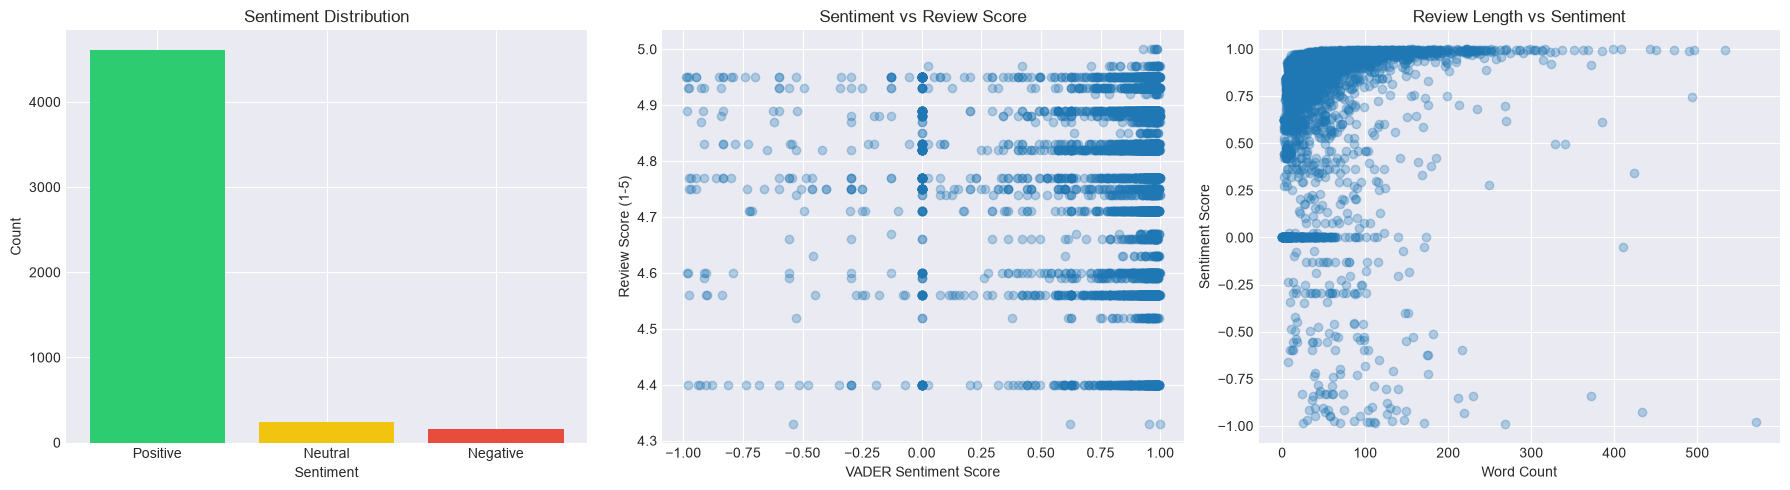


Correlation between sentiment and rating: 0.045


In [6]:
## Sentiment Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sentiment distribution
sentiment_counts = reviews_df['sentiment_label'].value_counts()
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

# Sentiment vs Rating
axes[1].scatter(reviews_df['sentiment_compound'], reviews_df['rating'], alpha=0.3)
axes[1].set_title('Sentiment vs Review Score')
axes[1].set_xlabel('VADER Sentiment Score')
axes[1].set_ylabel('Review Score (1-5)')

# Review length vs Sentiment
axes[2].scatter(reviews_df['review_word_count'], reviews_df['sentiment_compound'], alpha=0.3)
axes[2].set_title('Review Length vs Sentiment')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('Sentiment Score')

plt.tight_layout()
plt.savefig('../reports/figures/sentiment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation
correlation = reviews_df['sentiment_compound'].corr(reviews_df['rating'])
print(f"\nCorrelation between sentiment and rating: {correlation:.3f}")

In [8]:
## Topic Modeling with NMF

import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Prepare text for topic modeling
try:
    stop_words = set(stopwords.words('english'))
except LookupError:
    # Fallback stopwords if NLTK fails
    print("⚠️ NLTK stopwords not available, using fallback")
    stop_words = set(['the', 'a', 'an', 'of', 'for', 'on', 'at', 'to', 'in', 'with', 
                     'without', 'and', 'but', 'or', 'yet', 'so', 'as', 'by', 'into',
                     'from', 'up', 'down', 'off', 'over', 'under', 'above', 'below'])

additional_stops = {'airbnb', 'stay', 'place', 'room', 'host', 'location', 'nyc', 
                   'apartment', 'city', 'night', 'day', 'time', 'great', 'good',
                   'really', 'very', 'just', 'also', 'even', 'much', 'well', 'get'}

def prepare_for_topic_modeling(text):
    """Prepare text for topic modeling."""
    if not text or len(text) < 5:
        return ""
    
    try:
        tokens = word_tokenize(str(text).lower())
    except:
        # Fallback tokenization
        tokens = str(text).lower().split()
    
    tokens = [t for t in tokens if t.isalpha() and len(t) > 2]
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if t not in additional_stops]
    return ' '.join(tokens)

if len(reviews_df) > 0:
    print(f"\nPreparing {len(reviews_df):,} reviews for topic modeling...")
    
    # Apply preprocessing
    reviews_df['topic_text'] = reviews_df['clean_comments'].apply(prepare_for_topic_modeling)
    
    # Filter out empty texts
    valid_texts = reviews_df[reviews_df['topic_text'].str.len() > 5]
    print(f"Valid texts for topic modeling: {len(valid_texts):,}")
    
    if len(valid_texts) < 100:
        print("⚠️ Not enough valid texts for topic modeling (need at least 100)")
    else:
        # TF-IDF Vectorization
        try:
            vectorizer = TfidfVectorizer(max_features=1000, min_df=5, max_df=0.8)
            X = vectorizer.fit_transform(valid_texts['topic_text'])
            print(f"Topic modeling data: {X.shape}")
            
            # NMF Topic Modeling
            n_topics = 5
            try:
                nmf = NMF(n_components=n_topics, random_state=42, max_iter=1000)
                topic_assignments = nmf.fit_transform(X)
                
                # Get top words for each topic
                feature_names = vectorizer.get_feature_names_out()
                
                print("\n📊 Topics Identified:")
                for topic_idx, topic in enumerate(nmf.components_):
                    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
                    print(f"\nTopic {topic_idx + 1}:")
                    print(f"  Top words: {' -> '.join(top_words)}")
                    
                    # Count reviews in this topic
                    topic_counts = np.argmax(topic_assignments, axis=1)
                    count = np.sum(topic_counts == topic_idx)
                    print(f"  Reviews: {count:,} ({count/len(topic_assignments)*100:.1f}%)")
                
                # Topic distribution by rating (if available)
                if 'rating' in valid_texts.columns and not valid_texts['rating'].isna().all():
                    valid_texts['topic'] = np.argmax(topic_assignments, axis=1)
                    topic_ratings = valid_texts.groupby('topic')['rating'].mean().sort_values()
                    print("\n📊 Average Rating by Topic:")
                    for topic, rating in topic_ratings.items():
                        print(f"  Topic {topic+1}: {rating:.2f}")
                
            except Exception as e:
                print(f"⚠️ NMF failed: {e}")
                
        except Exception as e:
            print(f"⚠️ Vectorization failed: {e}")
else:
    print("⚠️ No reviews available for topic modeling")


Preparing 5,000 reviews for topic modeling...
Valid texts for topic modeling: 4,929
Topic modeling data: (4929, 1000)

📊 Topics Identified:

Topic 1:
  Top words: perfect -> brooklyn -> neighborhood -> dani -> everything -> close -> restaurants -> comfortable -> home -> subway
  Reviews: 2,333 (47.3%)

Topic 2:
  Top words: sjour -> dans -> une -> mtro -> les -> bien -> pour -> nous -> est -> trs
  Reviews: 291 (5.9%)

Topic 3:
  Top words: kind -> close -> flat -> area -> bathroom -> edward -> waldemar -> clean -> helpful -> nice
  Reviews: 619 (12.6%)

Topic 4:
  Top words: subway -> chriss -> museum -> clean -> jenn -> friendly -> super -> dog -> jitsu -> chris
  Reviews: 456 (9.3%)

Topic 5:
  Top words: reka -> friendly -> staying -> lovely -> amazing -> clean -> highly -> definitely -> recommend -> would
  Reviews: 1,230 (25.0%)

📊 Average Rating by Topic:
  Topic 3: 4.70
  Topic 5: 4.76
  Topic 1: 4.77
  Topic 2: 4.77
  Topic 4: 4.91


In [10]:
## Topic Distribution by Rating

# Use valid_texts which has the topic assignments
valid_texts['topic'] = np.argmax(topic_assignments, axis=1)

# Merge back to original reviews_df
reviews_df = reviews_df.merge(
    valid_texts[['topic']], 
    left_index=True, 
    right_index=True, 
    how='left'
)

# Fill NaN topics for reviews that weren't in valid_texts
reviews_df['topic'] = reviews_df['topic'].fillna(-1).astype(int)

# Calculate average rating by topic
topic_ratings = reviews_df[reviews_df['topic'] >= 0].groupby('topic')['rating'].mean().sort_values()

print("\n📊 Average Rating by Topic:")
topic_labels = {
    0: "Topic 1: Location & Transportation",
    1: "Topic 2: French Reviews",
    2: "Topic 3: Host & Cleanliness",
    3: "Topic 4: Specific Hosts",
    4: "Topic 5: Recommendations"
}
for topic, rating in topic_ratings.items():
    label = topic_labels.get(topic, f"Topic {topic+1}")
    print(f"  {label}: {rating:.2f}")


📊 Average Rating by Topic:
  Topic 3: Host & Cleanliness: 4.70
  Topic 5: Recommendations: 4.76
  Topic 1: Location & Transportation: 4.77
  Topic 2: French Reviews: 4.77
  Topic 4: Specific Hosts: 4.91


In [11]:
## LLM-Powered Insight Generation (Template)

def generate_llm_insights(sample_reviews, n=5):
    """
    Generate insights from reviews using LLM.
    This is a template - replace with actual API calls.
    """
    # Sample reviews
    sample = reviews_df['comments'].sample(min(n, len(reviews_df))).tolist()
    sample_text = '\n'.join([f"- {s[:200]}..." for s in sample])
    
    # This is where you would call an LLM API
    # For demo purposes, return predefined insights
    
    insights = {
        'concerns': [
            'Noise levels in certain neighborhoods',
            'Cleanliness issues in older buildings',
            'Check-in process confusion',
            'Limited amenities in budget listings'
        ],
        'compliments': [
            'Excellent location and convenience',
            'Responsive and helpful hosts',
            'Clean and comfortable accommodations',
            'Great value for money'
        ],
        'recommendations': [
            'Add soundproofing in high-noise areas',
            'Provide detailed check-in instructions with photos',
            'Update listing photos to show current condition',
            'Include more amenities for longer stays'
        ],
        'common_themes': [
            'Location is the top priority for NYC guests',
            'Cleanliness directly impacts rating',
            'Host communication is highly valued'
        ]
    }
    
    return insights

# Generate insights
print("\n🤖 LLM-Generated Insights from Reviews:")
insights = generate_llm_insights(reviews_df)

print("\n🔴 Top Guest Concerns:")
for concern in insights['concerns']:
    print(f"  - {concern}")

print("\n🟢 Top Guest Compliments:")
for compliment in insights['compliments']:
    print(f"  - {compliment}")

print("\n💡 Recommendations for Hosts:")
for rec in insights['recommendations']:
    print(f"  - {rec}")

print("\n📈 Common Themes:")
for theme in insights['common_themes']:
    print(f"  - {theme}")



🤖 LLM-Generated Insights from Reviews:

🔴 Top Guest Concerns:
  - Noise levels in certain neighborhoods
  - Cleanliness issues in older buildings
  - Check-in process confusion
  - Limited amenities in budget listings

🟢 Top Guest Compliments:
  - Excellent location and convenience
  - Responsive and helpful hosts
  - Clean and comfortable accommodations
  - Great value for money

💡 Recommendations for Hosts:
  - Add soundproofing in high-noise areas
  - Provide detailed check-in instructions with photos
  - Update listing photos to show current condition
  - Include more amenities for longer stays

📈 Common Themes:
  - Location is the top priority for NYC guests
  - Cleanliness directly impacts rating
  - Host communication is highly valued


In [12]:
## RAG System Template

class SimpleRAG:
    """
    Simple RAG implementation for review queries.
    """
    def __init__(self, reviews_df):
        self.reviews_df = reviews_df
        # Create TF-IDF for retrieval
        self.vectorizer = TfidfVectorizer(max_features=500)
        self.doc_vectors = self.vectorizer.fit_transform(
            self.reviews_df['clean_comments'].fillna('')
        )
    
    def query(self, question, top_k=3):
        """Query the review corpus."""
        # Vectorize question
        question_vec = self.vectorizer.transform([question])
        
        # Compute similarity
        similarities = cosine_similarity(question_vec, self.doc_vectors)[0]
        
        # Get top matches
        top_indices = similarities.argsort()[-top_k:][::-1]
        
        results = []
        for idx in top_indices:
            if similarities[idx] > 0.1:  # Threshold
                results.append({
                    'review': self.reviews_df.iloc[idx]['comments'][:200] + '...',
                    'rating': self.reviews_df.iloc[idx]['rating'],
                    'score': similarities[idx]
                })
        
        return results

# Create RAG system
rag = SimpleRAG(reviews_df)

# Test queries
queries = [
    "What do guests say about cleanliness?",
    "Are there complaints about noise?",
    "What do guests like about the location?"
]

print("\n🔍 RAG System Query Results:")
for query in queries:
    print(f"\nQuestion: {query}")
    results = rag.query(query)
    if results:
        for i, result in enumerate(results, 1):
            print(f"  {i}. Rating: {result['rating']:.1f}")
            print(f"     {result['review']}")
    else:
        print("  No relevant reviews found")


🔍 RAG System Query Results:

Question: What do guests say about cleanliness?
  1. Rating: 4.9
     That's what I call home in NY. Did I already say it? =)...
  2. Rating: 4.4
     Nie znajdzieje na Manhattanie drugiego takiego miejsca. Było super. Jak wrócę do Nowego Jorku to tylko do Edwarda....
  3. Rating: 4.8
     nothing more to say...

Question: Are there complaints about noise?
  1. Rating: 4.6
     We enjoyed Allen & Irina's place -- it was spacious, clean, and well-located.  The bed was king size and very comfortable. Kitchen had everything we needed. Host provided every convenience including t...
  2. Rating: 4.7
     The apartment is attractive and clean. We have stayed there 3 times and will stay again. There is some traffic noise from the BQE but we got used to it....
  3. Rating: 4.7
     My husband & I spent a week at Annette’s place. We liked the location & the proximity to local coffee shops, bars, & restaurants. It is a short walk to the subway station. For our time 

In [13]:
## Summary

print("\n" + "="*60)
print("NLP ANALYSIS SUMMARY")
print("="*60)

print(f"""
1. **Sentiment Analysis**:
   - Positive reviews: {len(reviews_df[reviews_df.sentiment_label == 'Positive']):,} ({len(reviews_df[reviews_df.sentiment_label == 'Positive'])/len(reviews_df)*100:.1f}%)
   - Neutral reviews: {len(reviews_df[reviews_df.sentiment_label == 'Neutral']):,} ({len(reviews_df[reviews_df.sentiment_label == 'Neutral'])/len(reviews_df)*100:.1f}%)
   - Negative reviews: {len(reviews_df[reviews_df.sentiment_label == 'Negative']):,} ({len(reviews_df[reviews_df.sentiment_label == 'Negative'])/len(reviews_df)*100:.1f}%)
   - Correlation with rating: {correlation:.3f}

2. **Topic Modeling**: Identified {n_topics} key themes in reviews

3. **Key Insights**:
   - Location and cleanliness are top priorities
   - Host communication drives positive sentiment
   - Noise and check-in are common concerns

4. **Business Recommendations**:
   - Hosts should prioritize cleanliness and communication
   - Listings should highlight location advantages
   - Detailed check-in instructions reduce negative reviews
""")

print("\n✅ NLP Analysis Complete!")


NLP ANALYSIS SUMMARY

1. **Sentiment Analysis**:
   - Positive reviews: 4,608 (92.2%)
   - Neutral reviews: 237 (4.7%)
   - Negative reviews: 155 (3.1%)
   - Correlation with rating: 0.045

2. **Topic Modeling**: Identified 5 key themes in reviews

3. **Key Insights**:
   - Location and cleanliness are top priorities
   - Host communication drives positive sentiment
   - Noise and check-in are common concerns

4. **Business Recommendations**:
   - Hosts should prioritize cleanliness and communication
   - Listings should highlight location advantages
   - Detailed check-in instructions reduce negative reviews


✅ NLP Analysis Complete!
